In [1]:
import pandas as pd
import geopandas as gpd
import shapely
import numpy as np
import json
from functools import partial
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

import nomad.io.base as loader
import nomad.stop_detection.utils as utils
import nomad.stop_detection.lachesis as LACHESIS
import nomad.stop_detection.dbscan as TADBSCAN
import nomad.stop_detection.grid_based as GRID_BASED # for oracle visits
import nomad.stop_detection.postprocessing as pp

import nomad.visit_attribution.visit_attribution as visits
import nomad.filters as filters
import nomad.city_gen as cg

from nomad.map_utils import blocks_to_mercator_gdf
from nomad.contact_estimation import compute_stop_detection_metrics
import warnings

In [3]:
with open('config_2_stops.json', 'r', encoding='utf-8') as f:
    config3 = json.load(f)

config=config3

In [4]:
poi_table = gpd.read_file(config["city_file"], layer="buildings").rename(columns={"id":"location"})
poi_table = blocks_to_mercator_gdf(poi_table, block_size=15, false_easting=-4265699.0, false_northing=4392976.0)

sparse_path=config["output_files"]["sparse_path"]
diaries_path=config["output_files"]["diaries_path"]

sparse_df = loader.from_file(sparse_path, format="parquet")
diaries_df = loader.from_file(diaries_path, format="parquet").rename(columns={"identifier":"user_id"})

In [5]:
import os
os.makedirs('figures', exist_ok=True)

In [35]:
one_user_df = sparse_df[sparse_df['user_id'] == 'admiring_keller']
pings_with_labels = TADBSCAN.ta_dbscan_labels(one_user_df,
                          time_thresh=60,
                          dist_thresh=20,
                          min_pts=4)
stops_for_user = TADBSCAN.ta_dbscan(one_user_df,
                          time_thresh=60,
                          dist_thresh=20,
                          min_pts=4)

In [36]:
one_user_df['cluster_label'] = pings_with_labels

/var/folders/nt/0tc5pmb17xd73rr4g1xb0g_00000gn/T/ipykernel_11145/3536381318.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  one_user_df['cluster_label'] = pings_with_labels


In [39]:
one_user_df['location'] = visits.point_in_polygon(
            one_user_df,
            method='majority',
            poi_table=poi_table, 
            data_crs='EPSG:3857',
            max_distance=10, 
            location_id='location', 
            x='x', 
            y='y'
        )

/var/folders/nt/0tc5pmb17xd73rr4g1xb0g_00000gn/T/ipykernel_11145/3374344625.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  one_user_df['location'] = visits.point_in_polygon(


In [63]:
locations = one_user_df.groupby('cluster_label')['location'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else None).reset_index()

In [61]:
locations.index.name = None

In [64]:
locations

,cluster_label,location
0,0,w-x17-y10
1,1,r-x19-y11


In [52]:
stops_for_user

,cluster,x,y,datetime,duration,user_id
0,0,-4.265442e+06,4.393146e+06,2024-06-01 00:07:33,76,admiring_keller
1,1,-4.265404e+06,4.393148e+06,2024-06-01 01:41:39,65,admiring_keller


In [31]:
visits.point_in_polygon(
            stops_for_user,
            poi_table=poi_table, 
            data_crs='EPSG:3857',
            max_distance=10, 
            location_id='location', 
            x='x', 
            y='y'
        )

0    w-x17-y10
1    r-x19-y11
Name: location, dtype: object

Processing users: 100%|██████████| 250/250 [03:50<00:00,  1.09it/s]


Computed metrics for 12500 user-algorithm combinations
   precision  recall   f1  missed_fraction  merged_fraction  split_fraction  \
0        0.0     0.0  0.0              1.0              0.0             0.0   
1        0.0     0.0  0.0              1.0              0.0             0.0   
2        0.0     0.0  0.0              1.0              0.0             0.0   
3        0.0     0.0  0.0              1.0              0.0             0.0   
4        0.0     0.0  0.0              1.0              0.0             0.0   

           user_id               algorithm  dist_thresh  
0  admiring_keller  lachesis_dist_thresh_1     1.989899  
1  admiring_keller  lachesis_dist_thresh_2     2.979798  
2  admiring_keller  lachesis_dist_thresh_3     3.969697  
3  admiring_keller  lachesis_dist_thresh_4     4.959596  
4  admiring_keller  lachesis_dist_thresh_5     5.949495  


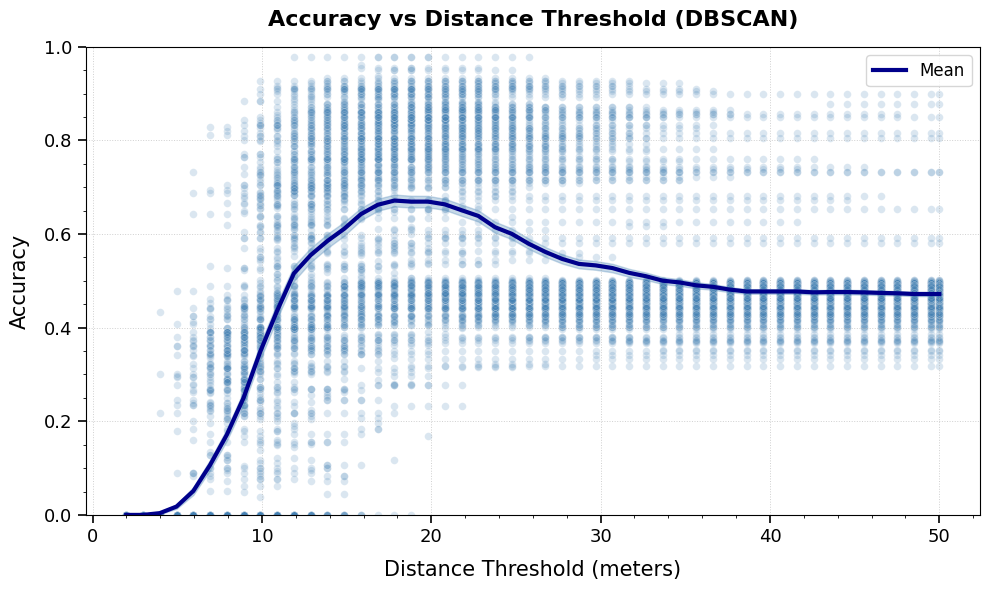

Number of unique dist_thresh values: 50


In [72]:
warnings.filterwarnings('ignore', message='Input is timezone-naive; assuming UTC')

dist_thresh_values = np.linspace(1, 50, 100)

config["algos"] = {
    **{f"lachesis_dist_thresh_{int(dr)}": {
        "func": TADBSCAN.ta_dbscan_labels,
        "params": {
            "time_thresh":60,
            "dist_thresh":dr,
            "min_pts":4
        }
    } for dr in dist_thresh_values}
}

results_list = []
for user in tqdm(diaries_df.user_id.unique(), desc='Processing users'):
    sparse = sparse_df.query("user_id==@user").copy()
    truth = diaries_df.query("user_id==@user").copy()
    
    # Run all Lachesis variations
    for algo_name, algo_config in config["algos"].items():
        # Run stop detection
        stops = TADBSCAN.ta_dbscan(sparse, **algo_config["params"], x="x", y="y", timestamp='timestamp')
        pings_with_labels = algo_config["func"](sparse, **algo_config["params"], x="x", y="y", timestamp='timestamp')
        sparse['cluster_label'] = pings_with_labels
        
        # Map stops to buildings
        sparse["location"] = visits.point_in_polygon(
            sparse,
            method='majority',
            poi_table=poi_table, 
            data_crs='EPSG:3857',
            max_distance=10, 
            location_id='location', 
            x='x', 
            y='y'
        )

        locations = sparse.groupby('cluster_label')['location'].agg(
            lambda x: x.mode()[0] if len(x.mode()) > 0 else None
        ).reset_index()
        
        # Merge on cluster column to properly align locations (only if stops exist)
        if not stops.empty:
            stops = stops.merge(
                locations.rename(columns={'cluster_label': 'cluster'}),
                on='cluster',
                how='left'
            )
        
        # Compute metrics
        metrics = compute_stop_detection_metrics(
            stops=stops,
            truth=truth,
            user_id=user,
            algorithm=algo_name,
            traj_cols={'location_id': 'location'},
            timestamp='timestamp'
        )
        
        # Add dist_thresh value to metrics
        metrics['dist_thresh'] = algo_config['params']['dist_thresh']
        
        results_list.append(metrics)
        
        # Clean up temporary columns for next iteration
        sparse.drop(columns=['cluster_label', 'location'], inplace=True)

# Convert to DataFrame
results_df = pd.DataFrame(results_list)

print(f"Computed metrics for {len(results_df)} user-algorithm combinations")
print(results_df.head())

# Plotting function adapted for dist_thresh
def plot_metric_dist_thresh(metric, title, save_path='figures'):
    """Plot a metric vs dist_thresh for Lachesis."""
    chart_df = results_df.groupby(['dist_thresh'])[metric].agg(['mean', 'sem']).reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Add scatter plot background (individual data points)
    sns.scatterplot(data=results_df, x='dist_thresh', y=metric,
                   alpha=0.2, s=30, ax=ax, color='steelblue')
    
    # Add line plot (mean values)
    ax.plot(chart_df['dist_thresh'], chart_df['mean'],
            color='darkblue', linewidth=3, label='Mean')
    
    # Add confidence band (mean ± SEM)
    ax.fill_between(chart_df['dist_thresh'],
                    chart_df['mean'] - chart_df['sem'],
                    chart_df['mean'] + chart_df['sem'],
                    alpha=0.3, color='steelblue')
    
    # Styling
    ax.set_xlabel('Distance Threshold (meters)', fontsize=15, labelpad=10)
    ax.set_ylabel(title, fontsize=15, labelpad=10)
    ax.set_ylim(0, 1)
    ax.set_title(f'{title} vs Distance Threshold (DBSCAN)', fontsize=16, pad=15, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6, linewidth=0.7)
    ax.tick_params(axis='both', which='major', labelsize=13, length=6, width=1.2)
    ax.minorticks_on()
    ax.legend(fontsize=12, frameon=True, loc='best')
    
    plt.tight_layout()
    plt.savefig(f"{save_path}/dbscan_dist_thresh_{metric}.svg", bbox_inches='tight')
    plt.savefig(f"{save_path}/dbscan_dist_thresh_{metric}.png", dpi=600, bbox_inches='tight')
    plt.show(block=False)
    plt.close()

# Plot all metrics
os.makedirs('figures', exist_ok=True)

metrics = {
    'recall': 'Accuracy',
}

for metric, title in metrics.items():
    plot_metric_dist_thresh(metric, title)
    print(f"Number of unique dist_thresh values: {results_df['dist_thresh'].nunique()}")


Processing users: 100%|██████████| 250/250 [02:49<00:00,  1.48it/s]


Computed metrics for 12500 user-algorithm combinations
   precision  recall   f1  missed_fraction  merged_fraction  split_fraction  \
0        0.0     0.0  0.0              1.0              0.0             0.0   
1        0.0     0.0  0.0              1.0              0.0             0.0   
2        0.0     0.0  0.0              1.0              0.0             0.0   
3        0.0     0.0  0.0              1.0              0.0             0.0   
4        0.0     0.0  0.0              1.0              0.0             0.0   

           user_id               algorithm  dist_thresh  
0  admiring_keller  lachesis_dist_thresh_1     1.989899  
1  admiring_keller  lachesis_dist_thresh_2     2.979798  
2  admiring_keller  lachesis_dist_thresh_3     3.969697  
3  admiring_keller  lachesis_dist_thresh_4     4.959596  
4  admiring_keller  lachesis_dist_thresh_5     5.949495  


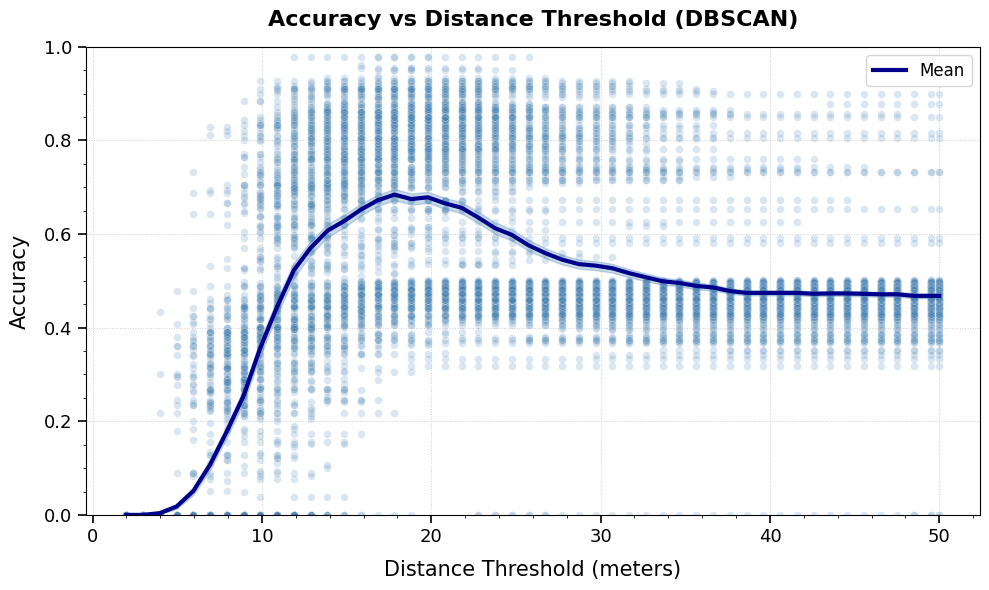

Number of unique dist_thresh values: 50


In [71]:
warnings.filterwarnings('ignore', message='Input is timezone-naive; assuming UTC')

dist_thresh_values = np.linspace(1, 50, 100)

config["algos"] = {
    **{f"lachesis_dist_thresh_{int(dr)}": {
        "func": TADBSCAN.ta_dbscan,
        "params": {
            "time_thresh":60,
            "dist_thresh":dr,
            "min_pts":4
        }
    } for dr in dist_thresh_values}
}

results_list = []
for user in tqdm(diaries_df.user_id.unique(), desc='Processing users'):
    sparse = sparse_df.query("user_id==@user").copy()
    truth = diaries_df.query("user_id==@user").copy()
    
    # Run all Lachesis variations
    for algo_name, algo_config in config["algos"].items():
        # Run stop detection
        stops = algo_config["func"](sparse, **algo_config["params"], x="x", y="y", timestamp='timestamp')
        
        # Map stops to buildings
        stops["location"] = visits.point_in_polygon(
            stops, 
            poi_table=poi_table, 
            data_crs='EPSG:3857',
            max_distance=10, 
            location_id='location', 
            x='x', 
            y='y'
        )
        
        # Compute metrics
        metrics = compute_stop_detection_metrics(
            stops=stops,
            truth=truth,
            user_id=user,
            algorithm=algo_name,
            traj_cols={'location_id': 'location'},
            timestamp='timestamp'
        )
        
        # Add dist_thresh value to metrics
        metrics['dist_thresh'] = algo_config['params']['dist_thresh']
        
        results_list.append(metrics)

# Convert to DataFrame
results_df = pd.DataFrame(results_list)

print(f"Computed metrics for {len(results_df)} user-algorithm combinations")
print(results_df.head())

# Plotting function adapted for dist_thresh
def plot_metric_dist_thresh(metric, title, save_path='figures'):
    """Plot a metric vs dist_thresh for Lachesis."""
    chart_df = results_df.groupby(['dist_thresh'])[metric].agg(['mean', 'sem']).reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Add scatter plot background (individual data points)
    sns.scatterplot(data=results_df, x='dist_thresh', y=metric,
                   alpha=0.2, s=30, ax=ax, color='steelblue')
    
    # Add line plot (mean values)
    ax.plot(chart_df['dist_thresh'], chart_df['mean'],
            color='darkblue', linewidth=3, label='Mean')
    
    # Add confidence band (mean ± SEM)
    ax.fill_between(chart_df['dist_thresh'],
                    chart_df['mean'] - chart_df['sem'],
                    chart_df['mean'] + chart_df['sem'],
                    alpha=0.3, color='steelblue')
    
    # Styling
    ax.set_xlabel('Distance Threshold (meters)', fontsize=15, labelpad=10)
    ax.set_ylabel(title, fontsize=15, labelpad=10)
    ax.set_ylim(0, 1)
    ax.set_title(f'{title} vs Distance Threshold (DBSCAN)', fontsize=16, pad=15, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6, linewidth=0.7)
    ax.tick_params(axis='both', which='major', labelsize=13, length=6, width=1.2)
    ax.minorticks_on()
    ax.legend(fontsize=12, frameon=True, loc='best')
    
    plt.tight_layout()
    plt.savefig(f"{save_path}/dbscan_dist_thresh_{metric}.svg", bbox_inches='tight')
    plt.savefig(f"{save_path}/dbscan_dist_thresh_{metric}.png", dpi=600, bbox_inches='tight')
    plt.show(block=False)
    plt.close()

# Plot all metrics
os.makedirs('figures', exist_ok=True)

# metrics = {
#     'precision': 'Precision',
#     'recall': 'Accuracy',
#     'f1': 'F1 Score',
#     'missed_fraction': 'Proportion of Stops Missed',
#     'merged_fraction': 'Proportion of Stops Merged',
#     'split_fraction': 'Proportion of Stops Split'
# }

metrics = {
    'recall': 'Accuracy',
}

for metric, title in metrics.items():
    plot_metric_dist_thresh(metric, title)

print(f"Number of unique dist_thresh values: {results_df['dist_thresh'].nunique()}")